In [1]:
# Cell A: train meta-model
import os, joblib
import numpy as np
from sklearn.linear_model import LogisticRegression

ARTIFACTS_DIR = "artifacts"
oof_path = os.path.join(ARTIFACTS_DIR, "oof_train_features.joblib")
oof_X, oof_y, classes = joblib.load(oof_path)

print("OOF feature shape:", oof_X.shape, "Labels shape:", oof_y.shape)
meta = LogisticRegression(C=1.0, max_iter=500, multi_class='multinomial', solver='lbfgs', n_jobs=-1)
meta.fit(oof_X, oof_y)
joblib.dump((meta, classes), os.path.join(ARTIFACTS_DIR, "meta_model.joblib"))
print("Trained and saved meta-model to artifacts/meta_model.joblib")


OOF feature shape: (11712, 9) Labels shape: (11712,)


C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Trained and saved meta-model to artifacts/meta_model.joblib


In [2]:
# Cell B: retrain base models on full train set and save (names must match those used earlier)
import joblib
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Load TF-IDF train data
X_train_tfidf, y_train = joblib.load(os.path.join(ARTIFACTS_DIR, "train_tfidf.joblib"))
X_test_tfidf,  y_test  = joblib.load(os.path.join(ARTIFACTS_DIR, "test_tfidf.joblib"))

# NB
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
joblib.dump((nb, list(nb.classes_)), os.path.join(ARTIFACTS_DIR, "nb_full.joblib"))
print("Saved nb_full.joblib")

# LR
lr = LogisticRegression(C=2.0, max_iter=500, multi_class='multinomial', solver='lbfgs', n_jobs=-1)
lr.fit(X_train_tfidf, y_train)
joblib.dump((lr, list(lr.classes_)), os.path.join(ARTIFACTS_DIR, "lr_full.joblib"))
print("Saved lr_full.joblib")

# SVM calibrated
svm_base = LinearSVC(C=1.0, max_iter=5000)
svm_cal = CalibratedClassifierCV(estimator=svm_base, cv=3, method='sigmoid')
svm_cal.fit(X_train_tfidf, y_train)
joblib.dump((svm_cal, list(svm_cal.classes_)), os.path.join(ARTIFACTS_DIR, "svm_cal_full.joblib"))
print("Saved svm_cal_full.joblib")


Saved nb_full.joblib


C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Saved lr_full.joblib
Saved svm_cal_full.joblib


In [3]:
# Cell C: create test meta-features, predict and compare
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# load models
nb, _ = joblib.load(os.path.join(ARTIFACTS_DIR, "nb_full.joblib"))
lr, _ = joblib.load(os.path.join(ARTIFACTS_DIR, "lr_full.joblib"))
svm_cal, _ = joblib.load(os.path.join(ARTIFACTS_DIR, "svm_cal_full.joblib"))
meta, classes = joblib.load(os.path.join(ARTIFACTS_DIR, "meta_model.joblib"))

# prepare test meta features
models = [("nb", nb), ("lr", lr), ("svm", svm_cal)]
n_models = len(models)
n_classes = len(classes)
X_test_meta = np.zeros((X_test_tfidf.shape[0], n_models * n_classes), dtype=np.float32)

col = 0
for name, m in models:
    prob = m.predict_proba(X_test_tfidf)
    # reorder columns to global classes if needed
    m_classes = list(m.classes_)
    if m_classes != classes:
        reorder = [m_classes.index(c) for c in classes]
        prob = prob[:, reorder]
    X_test_meta[:, col:col+n_classes] = prob
    col += n_classes

# meta predictions
y_pred_stack = meta.predict(X_test_meta)
y_proba_stack = meta.predict_proba(X_test_meta).max(axis=1)

# best base (choose LR) for comparison
y_pred_lr = lr.predict(X_test_tfidf)

print("Stacking accuracy:", accuracy_score(y_test, y_pred_stack))
print(classification_report(y_test, y_pred_stack))
print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# confusion matrices
cm_stack = confusion_matrix(y_test, y_pred_stack, labels=classes)
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=classes)
print("Confusion matrix (stacking):\n", cm_stack)


Stacking accuracy: 0.7844945355191257
              precision    recall  f1-score   support

    negative       0.82      0.92      0.87      1835
     neutral       0.62      0.51      0.56       620
    positive       0.79      0.62      0.70       473

    accuracy                           0.78      2928
   macro avg       0.74      0.68      0.71      2928
weighted avg       0.78      0.78      0.78      2928

Logistic Regression accuracy: 0.7756147540983607
              precision    recall  f1-score   support

    negative       0.80      0.93      0.86      1835
     neutral       0.62      0.47      0.54       620
    positive       0.80      0.56      0.66       473

    accuracy                           0.78      2928
   macro avg       0.74      0.66      0.69      2928
weighted avg       0.77      0.78      0.76      2928

Confusion matrix (stacking):
 [[1686  111   38]
 [ 262  316   42]
 [  98   80  295]]


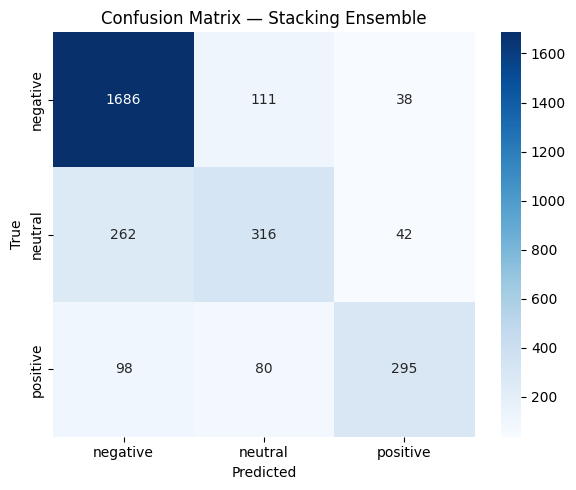

Saved figure: confusion_matrix_stacking.png


In [4]:
# Cell D: confusion matrix heatmap for stacking
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(6,5))
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Stacking Ensemble")
plt.tight_layout()
plt.savefig("confusion_matrix_stacking.png", dpi=200)
plt.show()
print("Saved figure: confusion_matrix_stacking.png")


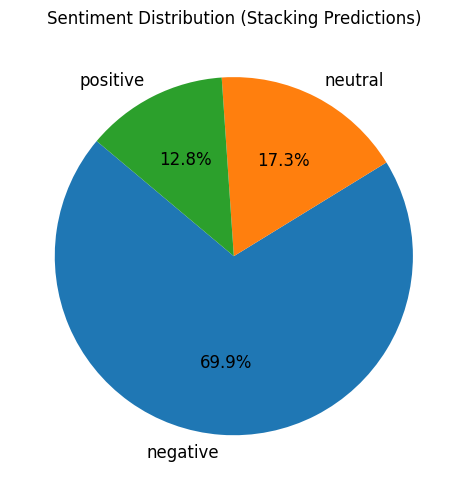

Saved figure: sentiment_distribution_stacking.png


In [5]:
# Cell E: sentiment distribution pie chart
import matplotlib.pyplot as plt
from collections import Counter

counts = Counter(y_pred_stack)
labels = [c for c in classes]
sizes = [counts.get(c,0) for c in labels]

plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, textprops={'fontsize':12})
plt.title("Sentiment Distribution (Stacking Predictions)")
plt.tight_layout()
plt.savefig("sentiment_distribution_stacking.png", dpi=200)
plt.show()
print("Saved figure: sentiment_distribution_stacking.png")


In [8]:
# Cell F: sample tweets table with predictions and confidences (saves as PNG)
import pandas as pd
import matplotlib.pyplot as plt

# load processed texts
proc_csv = "data/processed/processed_tweets.csv"
df_proc = pd.read_csv(proc_csv)

# select test indices and get corresponding rows
# we saved y_test as pandas Series earlier; reconstruct index mapping:
_, y_test_ser = joblib.load(os.path.join(ARTIFACTS_DIR, "test_tfidf.joblib"))
# Find sample rows from df_proc that are in test set by matching clean_text & label - approximate
test_texts = list(y_test_ser.index)  # if index alignment preserved
# Simpler: take 8 random test rows
np.random.seed(42)
sample_idx = np.random.choice(df_proc.index, size=8, replace=False)
sample_df = df_proc.loc[sample_idx, ['text','clean_text','airline_sentiment']].reset_index(drop=True)

# For each sample, compute TF-IDF -> meta features -> predict
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = joblib.load(os.path.join(ARTIFACTS_DIR, "tfidf_vectorizer.joblib"))

def predict_stack_for_text(text):
    ct = clean_text(text)
    v = tfidf.transform([ct])
    # base probs
    col = 0
    probs = []
    for name, m in models:
        p = m.predict_proba(v)
        m_classes = list(m.classes_)
        if m_classes != classes:
            reorder = [m_classes.index(c) for c in classes]
            p = p[:, reorder]
        probs.append(p[0])
    probs_concat = np.concatenate(probs)
    pred = meta.predict(probs_concat.reshape(1,-1))[0]
    conf = meta.predict_proba(probs_concat.reshape(1,-1)).max()
    # also record base contributions (max prob per base)
    base_contribs = [round(float(p.max()),3) for p in probs]
    return pred, float(conf), base_contribs

rows = []
for _, r in sample_df.iterrows():
    pred, conf, base_contribs = predict_stack_for_text(r['text'])
    rows.append({
        'text': r['text'],
        'true_label': r['airline_sentiment'],
        'pred_label': pred,
        'pred_conf': round(conf,3),
        'base_contribs': base_contribs
    })
table_df = pd.DataFrame(rows)

# display and save as image
print(table_df)
# save table to png using matplotlib
fig, ax = plt.subplots(figsize=(12, len(table_df)*0.7 + 1))
ax.axis('off')
tbl = ax.table(cellText=table_df.values, colLabels=table_df.columns, cellLoc='left', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.2)
plt.title("Sample Tweets — Predictions (Stacking)", fontsize=14)
plt.tight_layout()
plt.savefig("sample_tweets_predictions.png", dpi=200)
plt.show()
print("Saved table image: sample_tweets_predictions.png")


NameError: name 'clean_text' is not defined